# Loan Default Risk Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
loans = pd.read_csv("Downloads/datasets/loan_applications.csv")
borrowers = pd.read_csv("Downloads/datasets/borrower_profiles.csv")

## Quick Data Inspection

In [4]:
loans.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0


In [5]:
borrowers.head()

,borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,BRW-0001,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,BRW-0002,24,CO,High School,Full-Time,4,40188,543,Own,2,869
2,BRW-0003,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
3,BRW-0004,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928
4,BRW-0005,46,NY,High School,Full-Time,18,44528,715,Own,0,608


In [6]:
loans.shape

(601, 12)

In [7]:
borrowers.shape

(500, 11)

In [8]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   loan_id           601 non-null    object 
 1   borrower_id       601 non-null    object 
 2   application_date  601 non-null    object 
 3   loan_purpose      601 non-null    object 
 4   loan_amount       601 non-null    float64
 5   term_months       601 non-null    int64  
 6   interest_rate     601 non-null    float64
 7   monthly_payment   601 non-null    float64
 8   dti_ratio         601 non-null    float64
 9   loan_status       601 non-null    object 
 10  days_delinquent   601 non-null    int64  
 11  defaulted         601 non-null    int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 56.5+ KB


In [9]:
borrowers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   borrower_id            500 non-null    object
 1   age                    500 non-null    int64 
 2   state                  500 non-null    object
 3   education_level        500 non-null    object
 4   employment_status      500 non-null    object
 5   years_employed         500 non-null    int64 
 6   annual_income          500 non-null    int64 
 7   credit_score           500 non-null    int64 
 8   home_ownership         500 non-null    object
 9   dependents             500 non-null    int64 
 10  existing_monthly_debt  500 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 43.1+ KB


In [10]:
loans.describe()

,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted
count,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000,601.000000
mean,22148.252912,36.539101,10.641331,948.337654,49.680699,27.036606,0.242928
std,13215.261422,16.898192,2.251153,864.959543,24.113652,47.802845,0.429209
min,2000.000000,12.000000,5.860000,44.140000,7.600000,0.000000,0.000000
25%,10900.000000,24.000000,8.940000,359.860000,32.200000,0.000000,0.000000
50%,20400.000000,36.000000,10.540000,684.870000,48.100000,0.000000,0.000000
75%,32700.000000,48.000000,12.330000,1165.200000,62.400000,30.000000,0.000000
max,49800.000000,60.000000,15.860000,4262.690000,177.400000,180.000000,1.000000


In [11]:
borrowers.describe()

,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,44.986000,10.854000,64471.484000,704.952000,1.356000,1585.166000
std,13.539736,9.301706,28959.837645,97.339157,1.252358,1089.979915
min,22.000000,0.000000,12549.000000,528.000000,0.000000,124.000000
25%,33.000000,3.000000,42968.250000,617.750000,0.000000,788.750000
50%,45.000000,8.000000,59282.500000,708.000000,1.000000,1312.000000
75%,57.000000,17.000000,79780.500000,794.250000,2.000000,2131.750000
max,68.000000,35.000000,157047.000000,850.000000,4.000000,6130.000000


In [12]:
loans['application_date'] = pd.to_datetime(loans['application_date'])
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   loan_id           601 non-null    object        
 1   borrower_id       601 non-null    object        
 2   application_date  601 non-null    datetime64[ns]
 3   loan_purpose      601 non-null    object        
 4   loan_amount       601 non-null    float64       
 5   term_months       601 non-null    int64         
 6   interest_rate     601 non-null    float64       
 7   monthly_payment   601 non-null    float64       
 8   dti_ratio         601 non-null    float64       
 9   loan_status       601 non-null    object        
 10  days_delinquent   601 non-null    int64         
 11  defaulted         601 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 56.5+ KB


In [13]:
#Merge Datasets
df = loans.merge(borrowers, on ='borrower_id', how = 'left')
df.head()

,loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
0,LN-00001,BRW-0001,2024-01-08,Vacation,16100.0,36,13.05,542.86,55.5,Paid Off,0,0,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
1,LN-00002,BRW-0001,2024-08-13,Major Purchase,5600.0,48,14.21,153.62,40.4,Default,138,1,62,CT,High School,Self-Employed,6,31020,596,Rent,1,892
2,LN-00003,BRW-0002,2025-06-28,Moving,44700.0,36,12.37,1492.59,70.5,Paid Off,0,0,24,CO,High School,Full-Time,4,40188,543,Own,2,869
3,LN-00004,BRW-0003,2025-05-18,Auto Loan,9200.0,48,11.18,238.58,59.8,Default,34,1,50,NC,Bachelor,Contract,22,41014,611,Mortgage,0,1806
4,LN-00005,BRW-0004,2025-03-24,Moving,11200.0,36,9.66,359.61,44.1,Current,0,0,43,TX,High School,Full-Time,19,35036,701,Mortgage,2,928


In [14]:
df.shape

(601, 22)

## FEATURE ENGINEERING

In [15]:
#Credit Score Buckets
bins = [0, 599, 649, 699, 749, 850]
labels = ['520-599', '600-649', '650-699', '700-749', '750+']

df['credit_bucket'] = pd.cut(df['credit_score'], bins=bins, labels=labels)

In [16]:
credit_report = df.groupby('credit_bucket').agg(
    total_loans=('loan_id', 'count'),
    default_rate=('defaulted', 'mean'),
    avg_loan_amount=('loan_amount', 'mean'),
    avg_interest_rate=('interest_rate', 'mean'),
    avg_dti=('dti_ratio', 'mean'),
    avg_income=('annual_income', 'mean')
).reset_index()
credit_report


C:\Users\sonas\AppData\Local\Temp\ipykernel_11344\4080966192.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_report = df.groupby('credit_bucket').agg(


,credit_bucket,total_loans,default_rate,avg_loan_amount,avg_interest_rate,avg_dti,avg_income
0,520-599,116,0.491379,23481.896552,13.135862,58.048276,60327.181034
1,600-649,93,0.290323,19196.774194,12.013118,46.908602,62801.892473
2,650-699,75,0.280000,22700.000000,10.907333,48.593333,64492.840000
3,700-749,86,0.162791,22344.186047,10.435581,46.453488,65403.930233
4,750+,231,0.116883,22414.718615,8.826623,48.149351,68392.779221


In [17]:
df['credit_bucket'].value_counts(normalize=True)

credit_bucket
750+       0.384359
520-599    0.193012
600-649    0.154742
700-749    0.143095
650-699    0.124792
Name: proportion, dtype: float64

In [18]:
df['monthly_income'] = df['annual_income'] / 12

df['dti_calculated'] = df['existing_monthly_debt'] / df['monthly_income']

In [19]:
df.groupby('defaulted')['dti_calculated'].mean()

defaulted
0    0.285484
1    0.350955
Name: dti_calculated, dtype: float64

In [20]:
bins = [0, 0.2, 0.36, 0.5, 1]
labels = ['Low', 'Moderate', 'High', 'Very High']

df['dti_bucket'] = pd.cut(df['dti_calculated'], bins=bins, labels=labels)

In [21]:
#Employment Risk Flag
df['short_employment'] = np.where(df['years_employed'] < 2, 1, 0)

In [22]:
df['defaulted'] = df['loan_status'].apply(lambda x: 1 if x == "Default" else 0)

In [23]:
#OVERALL DEFAULT RATE
df['defaulted'].mean()

np.float64(0.24292845257903495)

## SEGMENTATION ANALYSIS

In [25]:
#Default rate by credit bucket
df.groupby('credit_bucket')['defaulted'].mean()

C:\Users\sonas\AppData\Local\Temp\ipykernel_11344\4057099210.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('credit_bucket')['defaulted'].mean()


credit_bucket
520-599    0.491379
600-649    0.290323
650-699    0.280000
700-749    0.162791
750+       0.116883
Name: defaulted, dtype: float64

In [26]:
#Default rate by DTI bucket
df.groupby('dti_bucket')['defaulted'].mean()

C:\Users\sonas\AppData\Local\Temp\ipykernel_11344\1221200151.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('dti_bucket')['defaulted'].mean()


dti_bucket
Low          0.167568
Moderate     0.201149
High         0.293103
Very High    0.426471
Name: defaulted, dtype: float64

In [29]:
#Default rate by employment status
df.groupby('employment_status')['defaulted'].mean()

employment_status
Contract         0.227273
Full-Time        0.239344
Part-Time        0.276923
Retired          0.233333
Self-Employed    0.247619
Name: defaulted, dtype: float64

In [30]:
#Default rate by loan purpose
df.groupby('loan_purpose')['defaulted'].mean()

loan_purpose
Auto Loan             0.271186
Business Loan         0.241379
Debt Consolidation    0.215686
Education             0.226415
Home Improvement      0.285714
Major Purchase        0.220588
Medical Expenses      0.205882
Moving                0.214286
Vacation              0.225806
Wedding               0.321429
Name: defaulted, dtype: float64

In [66]:
#Loan amount comparison
df.groupby('defaulted')['loan_amount'].mean()

default
0    22012.747253
1    22570.547945
Name: loan_amount, dtype: float64

## CORRELATION ANALYSIS

In [68]:
num_cols = df[['credit_score', 'dti_calculated', 'annual_income',
               'loan_amount', 'interest_rate', 'defaulted']]

num_cols.corr()

,credit_score,dti_calculated,annual_income,loan_amount,interest_rate,defaulted
credit_score,1.000000,-0.098699,0.109968,-0.003482,-0.755153,-0.286394
dti_calculated,-0.098699,1.000000,-0.027746,0.051407,0.083849,0.194226
annual_income,0.109968,-0.027746,1.000000,0.272778,-0.094122,-0.081546
loan_amount,-0.003482,0.051407,0.272778,1.000000,-0.002563,0.018116
interest_rate,-0.755153,0.083849,-0.094122,-0.002563,1.000000,0.198930
defaulted,-0.286394,0.194226,-0.081546,0.018116,0.198930,1.000000


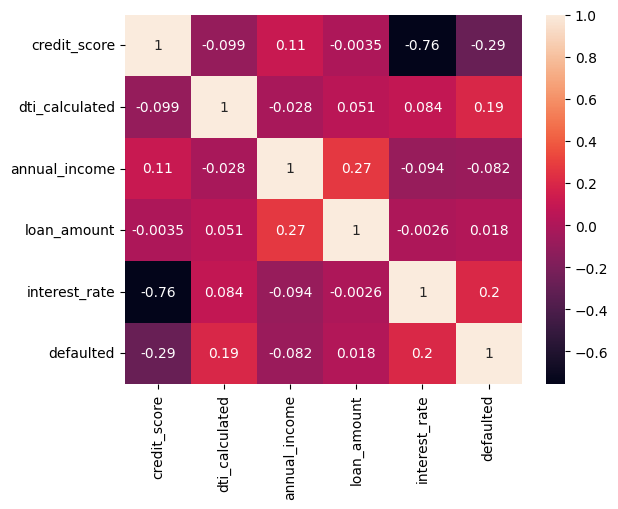

In [69]:
sns.heatmap(num_cols.corr(), annot=True)
plt.show()

## RISK SCORING MODEL

In [70]:
#Create risk score
df['risk_score'] = (
    (df['credit_score'] < 650).astype(int) +
    (df['dti_calculated'] > 0.4).astype(int) +
    (df['years_employed'] < 2).astype(int)
)

In [71]:
# Risk categories
df['risk_level'] = df['risk_score'].map({
    0: 'Low Risk',
    1: 'Medium Risk',
    2: 'High Risk',
    3: 'Very High Risk'
})

In [72]:
#Default rate by risk level
df.groupby('risk_level')['defaulted'].mean()

risk_level
High Risk         0.464286
Low Risk          0.118321
Medium Risk       0.258065
Very High Risk    0.700000
Name: defaulted, dtype: float64

## VISUALIZATIONS

C:\Users\sonas\AppData\Local\Temp\ipykernel_18344\3724149775.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('credit_bucket')['defaulted'].mean().plot(kind='bar')


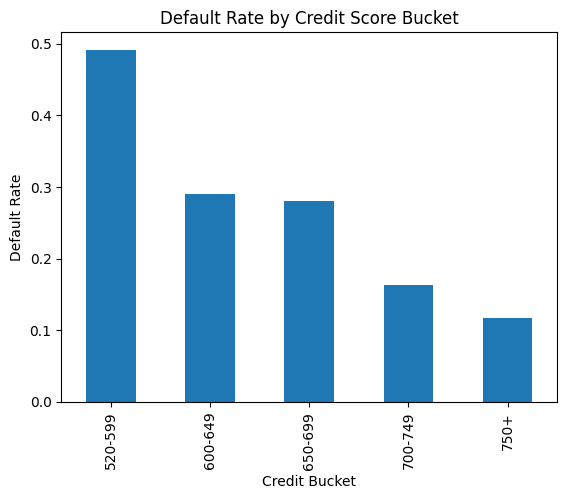

<Figure size 640x480 with 0 Axes>

In [80]:
#Credit bucket vs default rate
df.groupby('credit_bucket')['defaulted'].mean().plot(kind='bar')

plt.title("Default Rate by Credit Score Bucket")
plt.xlabel("Credit Bucket")
plt.ylabel("Default Rate")
plt.show()
plt.tight_layout()

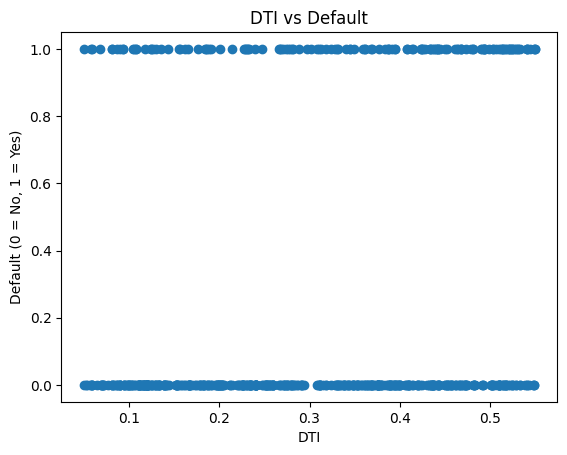

<Figure size 640x480 with 0 Axes>

In [79]:
#DTI vs default
plt.scatter(df['dti_calculated'], df['defaulted'])

plt.title("DTI vs Default")
plt.xlabel("DTI")
plt.ylabel("Default (0 = No, 1 = Yes)")
plt.show()
plt.tight_layout()

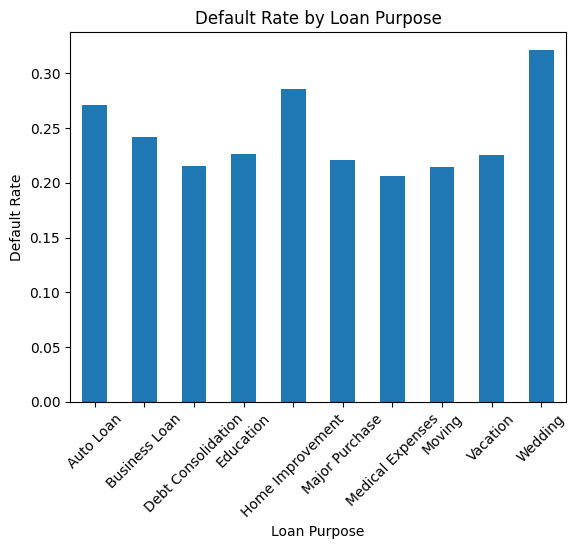

<Figure size 640x480 with 0 Axes>

In [78]:
#Loan purpose risk
df.groupby('loan_purpose')['defaulted'].mean().plot(kind='bar')

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.show()
plt.tight_layout()

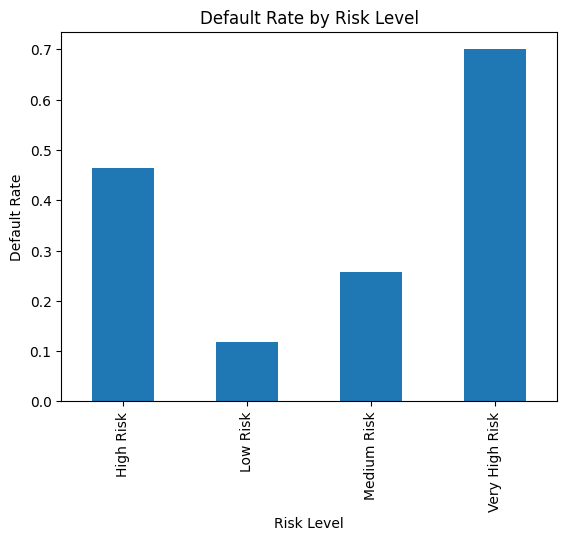

<Figure size 640x480 with 0 Axes>

In [77]:
#Risk level chart
df.groupby('risk_level')['defaulted'].mean().plot(kind='bar')

plt.title("Default Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Default Rate")
plt.show()
plt.tight_layout()

## INSIGHTS

### Credit Score is the Primary Driver of Default Risk

Default rates decline significantly as credit scores increase, falling from 49.1% in the 520–599 range to 11.7% for borrowers with scores above 750. This suggests that credit score remains the strongest indicator of repayment behavior and should continue to play a central role in lending decisions.

### High Debt Burden Increases Default Risk

Borrowers who defaulted had higher average debt-to-income (DTI) ratios than non-defaulted borrowers. Default rates increased steadily across DTI categories, reaching 42.6% among borrowers with very high DTI levels. This indicates that existing debt obligations are a key contributor to repayment risk.

### Risk-Based Pricing Aligns with Borrower Risk

Credit score and interest rate showed a strong negative correlation (-0.76), indicating that lower-credit borrowers are charged higher interest rates. While this suggests that pricing reflects borrower risk, default rates remain elevated among these borrowers, highlighting the need for stronger underwriting controls in addition to risk-based pricing.

### Loan Amount and Employment Status Have Limited Predictive Value

Loan amount showed virtually no relationship with default risk, while employment status exhibited only minor differences across borrower groups. These factors appear to be less influential than credit score and DTI when assessing credit risk.

### Composite Risk Score Effectively Segments Borrowers

A simple risk score combining credit score, DTI, and employment tenure produced clear separation between risk groups. Default rates increased from 11.8% for Low Risk borrowers to 70.0% for Very High Risk borrowers, demonstrating the value of combining multiple risk indicators when evaluating applicants.

## Conclusion

The analysis indicates that Horizon Financial Group's high default rate is primarily driven by borrowers with low credit scores and high debt-to-income ratios. Implementing stricter approval criteria for these borrowers and incorporating a multi-factor risk scoring approach could help reduce defaults and improve portfolio performance.
